<a href="https://colab.research.google.com/github/SSW1SSH/Code-Classifier/blob/main/Project_316.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
nltk.download('popular')
nltk.download('wordnet')

import pandas as pd
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, hamming_loss, f1_score
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score,hamming_loss

from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, hamming_loss

from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score

from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

In [ ]:
def nlbse_cleaner(text):
    text = text.lower()
    # Replace periods in Latin contractions to prevent sentence splitting errors
    text = re.sub(r'\b(e\.g\.|i\.e\.|etc\.)', lambda x: x.group(0).replace('.', ''), text)
    # Keep only safe technical characters
    text = re.sub(r'[^a-z0-9,. @#&^%!?\n]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load Parquet
splits = {'java_train': 'data/java_train-00000-of-00001.parquet', 'java_test': 'data/java_test-00000-of-00001.parquet', 'python_train': 'data/python_train-00000-of-00001.parquet', 'python_test': 'data/python_test-00000-of-00001.parquet', 'pharo_train': 'data/pharo_train-00000-of-00001.parquet', 'pharo_test': 'data/pharo_test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/NLBSE/nlbse25-code-comment-classification/" + splits["java_train"])

# Clean Text
df['cleaned_sentence'] = df['comment_sentence'].apply(nlbse_cleaner)

# Label Processing
df['y_matrix'] = df['labels'].apply(lambda x: np.array(x) if isinstance(x, (list, np.ndarray)) else np.array(eval(x)))

df[['cleaned_sentence', 'y_matrix']].to_parquet('cleaned_ready_for_features.parquet')

In [ ]:
# Generate TF-IDF Features
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=35000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_sentence'])

# Extract Manual Stylometric Features
def get_manual_features(dataframe):
    # Length of original sentence
    length = dataframe['comment_sentence'].str.len().values
    # Count of digits
    digit_count = dataframe['comment_sentence'].apply(lambda x: sum(c.isdigit() for c in x)).values
    # Count of special characters (@, #, !, etc.)
    special_char_count = dataframe['comment_sentence'].apply(lambda x: sum(not c.isalnum() for c in x)).values

    return np.column_stack((length, digit_count, special_char_count))

manual_features = get_manual_features(df)

# Combine both streams into the Final Matrix
# Convert manual features to sparse format to match TF-IDF
manual_features_sparse = csr_matrix(manual_features)

# This creates your final training data X
X_final = hstack([X_tfidf, manual_features_sparse])

print(f"Feature extraction successful. Matrix shape: {X_final.shape}")

Feature extraction successful. Matrix shape: (7614, 35003)


In [ ]:
# Prepare the y_matrix from your dataframe
# We must convert the list-like labels into a 2D NumPy array
y_matrix = np.stack(df['labels'].values)

# Split the hybrid feature matrix (X_final) and the newly defined y_matrix
X_train, X_test, y_train, y_test = train_test_split(X_final, y_matrix, test_size=0.2, random_state=42)

# Define and Initialize the Model
# 'class_weight=balanced' is key for the imbalanced labels we found
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))

# Train the Model
print("Training the Logistic Regression model...")
model.fit(X_train, y_train)

# Generate Predictions
y_pred = model.predict(X_test)

# Final Report
hl = hamming_loss(y_test, y_pred)
micro_f1 = f1_score(y_test, y_pred, average='micro')

report = classification_report(
    y_test,
    y_pred,
    target_names=[f"Label_{i}" for i in range(y_test.shape[1])],
    zero_division=0
)

print(f"\n--- Evaluation Results ---")
print(f"Hamming Loss: {hl:.4f}")
print(f"Micro-Averaged F1 Score: {micro_f1:.4f}")
print("\n--- Detailed Report per Label ---")

# 1. Raw probability scores (0.0 to 1.0) instead of hard 0/1
y_probs = model.predict_proba(X_test)

# 2. Custom thresholds
custom_thresholds = [0.55, 0.45, 0.50, 0.45, 0.40, 0.45, 0.4]

y_pred_tuned = np.zeros(y_probs.shape)
for i in range(len(custom_thresholds)):
    y_pred_tuned[:, i] = (y_probs[:, i] >= custom_thresholds[i]).astype(int)

# 3. Final Comparison
print(f"Tuned Micro-F1: {f1_score(y_test, y_pred_tuned, average='micro'):.4f}")
print("\n--- Optimized Multi-Label Report ---")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Training the Logistic Regression model...

--- Evaluation Results ---
Hamming Loss: 0.0687
Micro-Averaged F1 Score: 0.7741

--- Detailed Report per Label ---
Tuned Micro-F1: 0.7662

--- Optimized Multi-Label Report ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       715
           1       0.93      1.00      0.96        50
           2       0.42      0.44      0.43       106
           3       0.85      0.78      0.81       436
           4       0.59      0.88      0.71       185
           5       0.38      0.82      0.52        22
           6       0.33      0.45      0.38        69

   micro avg       0.73      0.80      0.77      1583
   macro avg       0.62      0.75      0.67      1583
weighted avg       0.75      0.80      0.77      1583
 samples avg       0.76      0.82      0.77      1583



In [ ]:
from sklearn.naive_bayes import ComplementNB

# Model 2: Complement Naive Bayes (Better for imbalanced text datasets)
# ComplementNB is specifically designed to handle imbalanced classes
nb_model = OneVsRestClassifier(ComplementNB())

print("Training Complement Naive Bayes...")

# Train model
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Evaluation
nb_hl = hamming_loss(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb, average='micro')

print("\n--- Naive Bayes Evaluation Results ---")
print(f"Hamming Loss: {nb_hl:.4f}")
print(f"Micro-Averaged F1 Score: {nb_f1:.4f}")

print("\n--- Detailed Multi-Label Report (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Training Complement Naive Bayes...

--- Naive Bayes Evaluation Results ---
Hamming Loss: 0.1139
Micro-Averaged F1 Score: 0.5316

--- Detailed Multi-Label Report (Naive Bayes) ---
              precision    recall  f1-score   support

           0       0.68      0.96      0.80       715
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00       106
           3       0.75      0.01      0.01       436
           4       0.00      0.00      0.00       185
           5       0.00      0.00      0.00        22
           6       0.00      0.00      0.00        69

   micro avg       0.68      0.44      0.53      1583
   macro avg       0.20      0.14      0.12      1583
weighted avg       0.51      0.44      0.36      1583
 samples avg       0.45      0.45      0.45      1583



In [ ]:
# 3. Random Forest Model
# We use OneVsRestClassifier for the multi-label task
# 'n_estimators=100' provides a robust ensemble of trees
# 'class_weight=balanced' is critical for handling the imbalanced labels identified in the sources
rf_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42))

# 2. Train the Model
print("Training Random Forest on hybrid features...")
rf_model.fit(X_train, y_train)

# 3. Generate Predictions
y_pred_rf = rf_model.predict(X_test)

# 4. Empirical Evaluation
hl_rf = hamming_loss(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='micro')

print(f"\n--- Random Forest Evaluation Results ---")
print(f"Hamming Loss: {hl_rf:.4f}")
print(f"Micro-Averaged F1 Score: {f1_rf:.4f}")
print("\n--- Detailed Multi-Label Report (Random Forest) ---")
print(classification_report(y_test,
    y_pred_rf,
    target_names=[f"Label_{i}" for i in range(y_test.shape[1])],zero_division=0))

Training Random Forest on hybrid features...

--- Random Forest Evaluation Results ---
Hamming Loss: 0.0524
Micro-Averaged F1 Score: 0.8151

--- Detailed Multi-Label Report (Random Forest) ---
              precision    recall  f1-score   support

     Label_0       0.81      0.93      0.87       715
     Label_1       0.98      0.94      0.96        50
     Label_2       0.92      0.21      0.34       106
     Label_3       0.95      0.77      0.85       436
     Label_4       0.86      0.74      0.79       185
     Label_5       0.88      0.64      0.74        22
     Label_6       0.67      0.14      0.24        69

   micro avg       0.86      0.78      0.82      1583
   macro avg       0.86      0.62      0.68      1583
weighted avg       0.86      0.78      0.79      1583
 samples avg       0.80      0.80      0.80      1583



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score
from sklearn.preprocessing import MaxAbsScaler

# 1. Scale features to help SVM convergence
# MaxAbsScaler is used because it maintains the sparsity of X_train
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define and Initialize the Linear SVM Model
# Increased max_iter and used scaling for better convergence
svm_classifier = OneVsRestClassifier(
    LinearSVC(class_weight='balanced', max_iter=10000, random_state=42, dual=True)
)

# 3. Train the Model
print("Training Linear SVM on scaled features...")
svm_classifier.fit(X_train_scaled, y_train)

# 4. Generate Predictions
y_pred_svm = svm_classifier.predict(X_test_scaled)

# 5. Evaluation
svm_hl = hamming_loss(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='micro')

print(f"\n--- SVM Evaluation Results ---")
print(f"Hamming Loss: {svm_hl:.4f}")
print(f"Micro-Averaged F1 Score: {svm_f1:.4f}")
print("\n--- Detailed Multi-Label Report (SVM) ---")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Training Linear SVM on scaled features...

--- SVM Evaluation Results ---
Hamming Loss: 0.0667
Micro-Averaged F1 Score: 0.7679

--- Detailed Multi-Label Report (SVM) ---
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       715
           1       0.96      0.94      0.95        50
           2       0.47      0.29      0.36       106
           3       0.83      0.78      0.81       436
           4       0.83      0.66      0.74       185
           5       0.33      0.73      0.45        22
           6       0.55      0.23      0.33        69

   micro avg       0.79      0.74      0.77      1583
   macro avg       0.69      0.64      0.64      1583
weighted avg       0.79      0.74      0.76      1583
 samples avg       0.74      0.76      0.74      1583



In [ ]:
# 5. Initialize the MLP (Neural Network)
# 'hidden_layer_sizes' defines the architecture (100 neurons in one layer)
# 'max_iter' corresponds to the number of epochs (passes over the data)
mlp_model = OneVsRestClassifier(MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False # Set to True to see the 'epochs'/loss in real-time
))

# 2. Train the Model
print("Training Multi-Layer Perceptron...")
mlp_model.fit(X_train, y_train)

# 3. Generate Predictions
y_pred_mlp = mlp_model.predict(X_test)

# 4. Evaluation
mlp_hl = hamming_loss(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp, average='micro')

print(f"\n--- MLP Evaluation Results ---")
print(f"Hamming Loss: {mlp_hl:.4f}")
print(f"Micro-Averaged F1 Score: {mlp_f1:.4f}")
print("\n--- Detailed Multi-Label Report (MLP) ---")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

Training Multi-Layer Perceptron...

--- MLP Evaluation Results ---
Hamming Loss: 0.0705
Micro-Averaged F1 Score: 0.7500

--- Detailed Multi-Label Report (MLP) ---
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       715
           1       0.95      0.80      0.87        50
           2       0.71      0.24      0.35       106
           3       0.83      0.71      0.76       436
           4       0.88      0.56      0.69       185
           5       0.00      0.00      0.00        22
           6       0.00      0.00      0.00        69

   micro avg       0.79      0.71      0.75      1583
   macro avg       0.59      0.46      0.50      1583
weighted avg       0.75      0.71      0.72      1583
 samples avg       0.72      0.73      0.72      1583



In [ ]:
# Split the original sentences using the same random seed
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['comment_sentence'],
    y_matrix,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import numpy as np

# 1. Initialize Bag-of-Words Vectorizer
bow_vectorizer = CountVectorizer(ngram_range=(1, 3))

# 2. Transform the cleaned code snippets
X_bow_text = bow_vectorizer.fit_transform(df['cleaned_sentence'])

# 3. Memory-efficient Combine: Use scipy.sparse.hstack instead of np.hstack
# This avoids converting the sparse matrix to a massive dense array
manual_features_sparse = csr_matrix(manual_features)
X_bow_final = hstack([X_bow_text, manual_features_sparse])

# 4. Split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow_final, y_matrix, test_size=0.2, random_state=42
)

print(f"BoW Hybrid Matrix created efficiently. Training shape: {X_train_bow.shape}")

BoW Hybrid Matrix created efficiently. Training shape: (6091, 79005)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, hamming_loss

# Initialize RF with balanced weights for the noisy/imbalanced rule-based labels
rf_bow_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42))

print("Training Random Forest (BoW Baseline)...")
rf_bow_model.fit(X_train_bow, y_train)

# Predictions and Evaluation
y_pred_rf_bow = rf_bow_model.predict(X_test_bow)

print(f"\n--- Random Forest (BoW) Results ---")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_rf_bow):.4f}")
print(f"Micro-F1 Score: {f1_score(y_test, y_pred_rf_bow, average='micro'):.4f}")

Training Random Forest (BoW Baseline)...

--- Random Forest (BoW) Results ---
Hamming Loss: 0.0483
Micro-F1 Score: 0.8293


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MaxAbsScaler

# Scaling is essential for SVM convergence, especially with hybrid features
scaler = MaxAbsScaler()
X_train_bow_scaled = scaler.fit_transform(X_train_bow)
X_test_bow_scaled = scaler.transform(X_test_bow)

# Initialize Linear SVM with a more robust approach
# MaxAbsScaler keeps the data sparse while helping convergence
svm_bow_model = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, max_iter=10000, dual=True))

print("Training SVM (BoW Baseline) with scaled features...")
svm_bow_model.fit(X_train_bow_scaled, y_train)

# Predictions and Evaluation
y_pred_svm_bow = svm_bow_model.predict(X_test_bow_scaled)

print(f"\n--- SVM (BoW) Results ---")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_svm_bow):.4f}")
print(f"Micro-F1 Score: {f1_score(y_test, y_pred_svm_bow, average='micro'):.4f}")

Training SVM (BoW Baseline) with scaled features...

--- SVM (BoW) Results ---
Hamming Loss: 0.0568
Micro-F1 Score: 0.8034


In [ ]:
import pandas as pd

# Collect metrics from all models
results_data = {
    'Model': ['Logistic Regression (Tuned)', 'Complement Naive Bayes', 'Random Forest', 'Linear SVM', 'MLP (Neural Net)', 'RF (BoW Baseline)', 'SVM (BoW Baseline)'],
    'Micro-F1': [
        f1_score(y_test, y_pred_tuned, average='micro'),
        nb_f1,
        f1_rf,
        svm_f1,
        mlp_f1,
        f1_score(y_test, y_pred_rf_bow, average='micro'),
        f1_score(y_test, y_pred_svm_bow, average='micro')
    ],
    'Hamming Loss': [
        hamming_loss(y_test, y_pred_tuned),
        nb_hl,
        hl_rf,
        svm_hl,
        mlp_hl,
        hamming_loss(y_test, y_pred_rf_bow),
        hamming_loss(y_test, y_pred_svm_bow)
    ]
}

comparison_df = pd.DataFrame(results_data).sort_values(by='Micro-F1', ascending=False)

print("--- Model Performance Comparison ---")
display(comparison_df)


--- Model Performance Comparison ---


,Model,Micro-F1,Hamming Loss
5,RF (BoW Baseline),0.829301,0.048307
2,Random Forest,0.815084,0.052434
6,SVM (BoW Baseline),0.803374,0.056843
3,Linear SVM,0.767875,0.066692
0,Logistic Regression (Tuned),0.766214,0.072695
4,MLP (Neural Net),0.750000,0.070537
1,Complement Naive Bayes,0.531636,0.113873


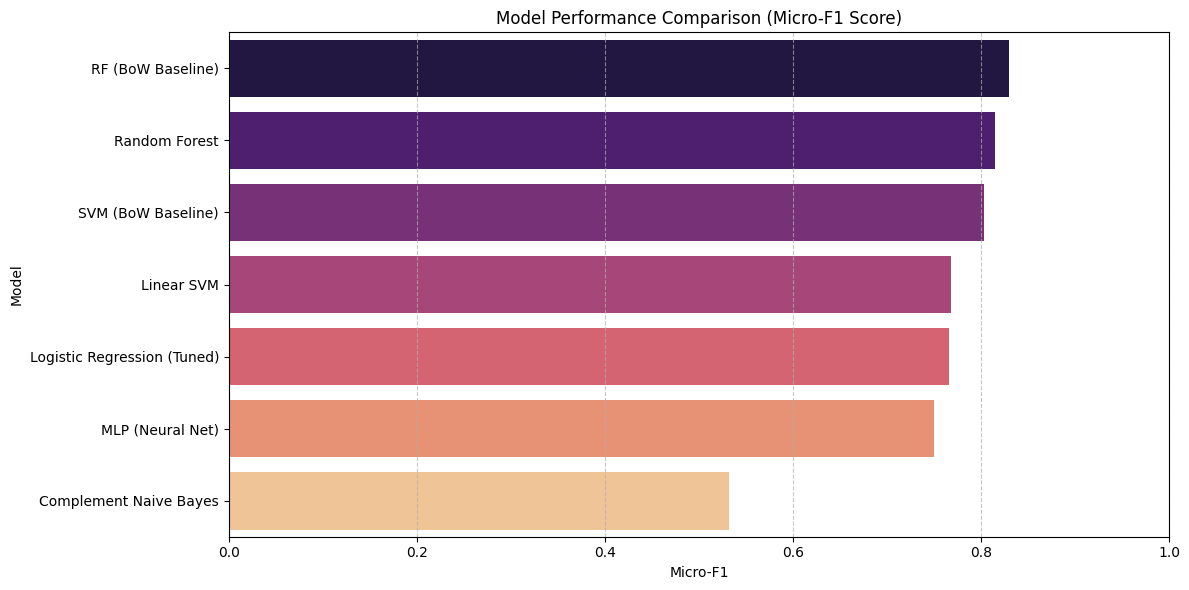

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Model Comparison Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Micro-F1', y='Model', data=comparison_df, palette='magma', hue='Model', legend=False)
plt.title('Model Performance Comparison (Micro-F1 Score)')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

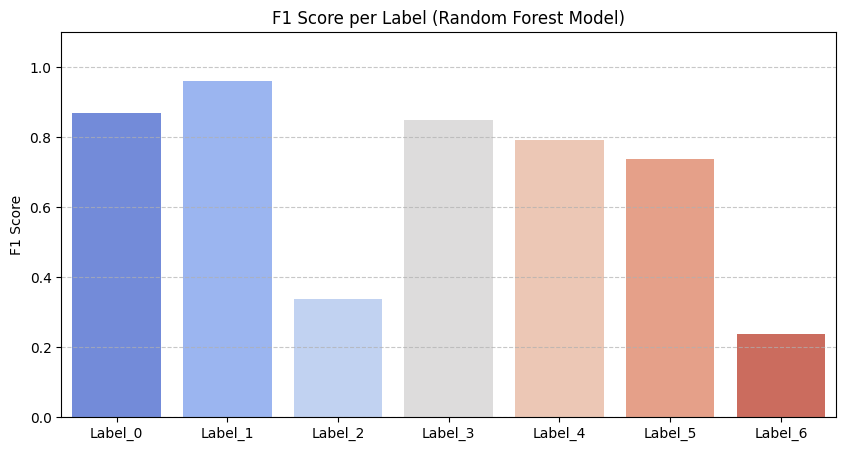

In [ ]:
from sklearn.metrics import f1_score

# 2. Per-Label Comparison (Using Random Forest as it performed well)
# Calculate F1 for each label individually
f1_per_label = f1_score(y_test, y_pred_rf, average=None)
label_names = [f'Label_{i}' for i in range(len(f1_per_label))]

plt.figure(figsize=(10, 5))
sns.barplot(x=label_names, y=f1_per_label, palette='coolwarm', hue=label_names, legend=False)
plt.title('F1 Score per Label (Random Forest Model)')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def classify_quality(prediction_row):
    # Mapping logic
    # GOOD: Summary (0), Usage (3), Rationale (4)
    if prediction_row[0] == 1 or prediction_row[3] == 1 or prediction_row[4] == 1:
        return "GOOD: Informative"

    # QUESTIONABLE: Warning (5), Ownership (1), Expand (2)
    elif prediction_row[5] == 1 or prediction_row[1] == 1 or prediction_row[2] == 1:
        return "QUESTIONABLE: High-Risk"

    # BAD: Task (6)
    elif prediction_row[6] == 1:
        return "BAD: Technical Debt"

    else:
        return "UNCATEGORIZED"

# Create the final audit dataframe
audit_report = pd.DataFrame({
    'Comment_Text': X_test_text.values,
    'Quality_Rating': [classify_quality(row) for row in y_pred_tuned]
})

# Display a sample of the results
print(audit_report.head(35))

                                         Comment_Text           Quality_Rating
0        * @see org.eclipse.debug.ui.actions.Debug...        GOOD: Informative
1   \t * @return the string handle identifier, or ...        GOOD: Informative
2                                   @code IOException        GOOD: Informative
3      common utility functions for @link logparser .        GOOD: Informative
4        * Performs some memory intensive operatio...        GOOD: Informative
5     // too many "unchecked generic array creations"        GOOD: Informative
6                                * @param application        GOOD: Informative
7                       // Renew token as the renewer        GOOD: Informative
8                                 \t * @param monitor        GOOD: Informative
9                               //FULL_BUILD or CLEAN        GOOD: Informative
10   Returns the full path to the Jar containing t...        GOOD: Informative
11                                    but mandatory 

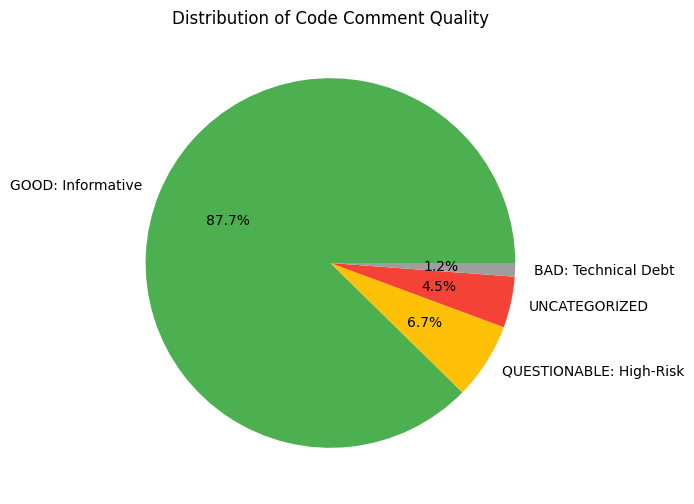

In [ ]:
import matplotlib.pyplot as plt

# Count the ratings
quality_counts = audit_report['Quality_Rating'].value_counts()

# Plot it
plt.figure(figsize=(10,6))
quality_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336', '#9E9E9E'])
plt.title("Distribution of Code Comment Quality")
plt.ylabel("")
plt.show()

In [ ]:
# End prompt FUNCTION — RANDOM FOREST + BAG OF WORDS

from scipy.sparse import csr_matrix, hstack
import numpy as np

def audit_code_comment(raw_comment):

    # 1. MANUAL STYLOMETRIC FEATURES

    length = len(raw_comment)

    digit_count = sum(c.isdigit() for c in raw_comment)

    special_char_count = sum(
        not c.isalnum() and not c.isspace()
        for c in raw_comment
    )

    manual_features = np.array([
        [length, digit_count, special_char_count]
    ])

    manual_features_sparse = csr_matrix(manual_features)

    # 2. BAG-OF-WORDS FEATURE EXTRACTION

    text_features = bow_vectorizer.transform([raw_comment])

    # 3. HYBRID FEATURE FUSION

    final_input = hstack([
        text_features,
      manual_features_sparse
    ])

    # 4. MODEL PREDICTION

    prediction = rf_bow_model.predict(final_input)

    prediction_row = prediction[0]


    # 5. LABEL MAPPING

    label_names = [
        "SUMMARY",
        "OWNERSHIP",
        "EXPAND",
        "USAGE",
        "RATIONALE",
        "WARNING",
        "TASK"
    ]

    predicted_labels = [
        label_names[i]
        for i in range(len(prediction_row))
        if prediction_row[i] == 1
    ]

    # 6. QUALITY AUDIT INTERPRETATION


    if prediction_row[6] == 1:
        quality_rating = "BAD: Technical Debt"

    elif (
        prediction_row[5] == 1 or
        prediction_row[1] == 1 or
        prediction_row[2] == 1
    ):
        quality_rating = "QUESTIONABLE: High-Risk"

    elif (
        prediction_row[0] == 1 or
        prediction_row[3] == 1 or
        prediction_row[4] == 1
    ):
        quality_rating = "GOOD: Informative"

    else:
        quality_rating = "UNCATEGORIZED"


    # 7. FINAL OUTPUT

    print("\n========== CODE AUDIT RESULTS ==========")

    print(f"\nInput Comment:\n{raw_comment}")

    print("\nPredicted Categories:")

    if predicted_labels:
        for label in predicted_labels:
            print(f"- {label}")
    else:
        print("- NONE DETECTED")

    print(f"\nAudit Interpretation: {quality_rating}")

    print("\n========================================")

In [ ]:
# Test 1
audit_code_comment(
    "This function calculates the total salary for all employees."
)


========== CODE AUDIT RESULTS ==========

Input Comment:
This function calculates the total salary for all employees.

Predicted Categories:
- SUMMARY

Audit Interpretation: GOOD: Informative



In [ ]:
# Test 2
audit_code_comment(
    " * @author crazybob@google.com (Bob Lee)"
)


========== CODE AUDIT RESULTS ==========

Input Comment:
 * @author crazybob@google.com (Bob Lee)

Predicted Categories:
- OWNERSHIP

Audit Interpretation: QUESTIONABLE: High-Risk



In [ ]:
# Test 3
audit_code_comment(
    "but mandatory."
)


========== CODE AUDIT RESULTS ==========

Input Comment:
but mandatory.

Predicted Categories:
- EXPAND
- TASK

Audit Interpretation: BAD: Technical Debt



In [ ]:
# Test 4
audit_code_comment(
    "p would be flagged as having called @code sqrt with an illegal argument."
)


========== CODE AUDIT RESULTS ==========

Input Comment:
p would be flagged as having called @code sqrt with an illegal argument.

Predicted Categories:
- NONE DETECTED

Audit Interpretation: UNCATEGORIZED

